# Input Data Access

This notebook opens the GCM data the SRM downscaling pipeline started from: the daily output of `CESM2-WACCM6` and `UKESM1-1-LL`, harmonized but **before** any bias correction or downscaling.

It is the first stage of a three-stage chain:

| Stage | What it is | Grid | Where |
|---|---|---|---|
| **Input** (this notebook) | GCM daily output with CMIP variable names and units, a proleptic Gregorian calendar and longitudes -180 to 180 | native: 192 x 288 (`CESM2-WACCM6`), 144 x 192 (`UKESM1-1-LL`) | `carbonplan-srm` S3 bucket |
| **Bias-corrected** | the input after quantile-mapping bias correction | the same native grid | published store, `debiased_coarse` product |
| **Downscaled** | the bias-corrected data disaggregated to 0.25 degrees | 721 x 1440 | published store, default product |

Use the downscaled product for impact analysis, the bias-corrected product to separate what bias correction did from what downscaling added, and the input to see the GCM's own values.

> **Where the data lives.** The input stores are on CarbonPlan's `carbonplan-srm` bucket (anonymous, read-only) until they move to Source Cooperative. When they do, only the location constants in Section 1 change.

Data associated with this repository are subject to additional [terms of data access](https://carbonplan.github.io/srm-downscaling/terms-of-data-access.html).

**Contents:**
1. Opening the input stores
2. Choosing a dataset
3. What is in a store
4. What a request costs
5. What bias correction changed
6. Export

## Setup

Follow the [installation instructions](https://github.com/carbonplan/srm-downscaling-data-utils#installation) in the README, then launch JupyterLab with `pixi run jupyter lab`. To run the whole notebook without opening it:

```bash
pixi run jupyter nbconvert --to notebook --execute --inplace notebooks/input-data.ipynb
```

**If you only want a file**, `scripts/download.sh` downloads input subsets directly:

```bash
./scripts/download.sh --scenario ssp245 --product input --list-members
./scripts/download.sh --scenario ssp245 --product input \
    --point 28.6 77.2 --start 2050-01-01 --end 2059-12-31
```

In [1]:
import functools
from pathlib import Path

import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from zarr.core.sync import sync

## 1. Opening the input stores

The input stores are laid out differently from the published output, and the helpers below account for that:

- **One group per scenario, holding every variable.** A variable's array has dims `(ensemble_member, time, lat, lon)`; there is no downscaling-method level, because no method has been applied yet.
- **Gaps are NaN.** A group's time axis spans the whole scenario, so a member that lacks a variable, or some years, holds NaN there rather than being absent.
- **Coverage comes from the chunk manifest.** The stores were written without all-NaN chunks, so the shards an array actually stores show which members carry it and over which years. Listing them takes about 0.1 s and reads no data.

`load_input_store(...)` returns one member's variable on `(time, lat, lon)`. It also corrects one stale label: the `CESM2-WACCM6` store predates the model's rename and records the old name in its `model` attribute, so the loader sets the current name and notes the change in `model_id_correction`. Provenance attributes such as `source_id` are left as they are.

This cell is a self-contained copy of `scripts/input_access.py`, so the notebook runs on its own.

In [2]:
# ===== No modification needed - opens the processed GCM input stores =====
# Everything that changes when the input stores move to Source Cooperative is in this block.
INPUT_BUCKET = "carbonplan-srm"
INPUT_REGION = "us-west-2"
INPUT_PREFIX = "input/processed"
INPUT_BRANCH = "main"

# The S3 store names predate the model rename and cannot change; you only ever use the keys.
# cesm2_waccm.icechunk (underscore) also exists next to cesm2-waccm.icechunk and is empty.
STORES = {"CESM2-WACCM6": "cesm2-waccm", "UKESM1-1-LL": "ukesm"}
GCMS = list(STORES)
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds", "hurs"]

# The published output, used in Section 5 to compare with the bias-corrected data.
OUTPUT_BUCKET = "us-west-2.opendata.source.coop"
OUTPUT_PREFIX = "carbonplan/srm-downscaling/output/production"
OUTPUT_BRANCH = "v1.0.0"
OUTPUT_STORES = {"CESM2-WACCM6": "CESM2-WACCM6-ERA5-global", "UKESM1-1-LL": "UKESM1-1-LL-ERA5-global"}

# Default members are the ones pinned for the downscaled output, so a default input is the
# run the default downscaled data was built from. "*" covers variables without their own entry.
DEFAULT_MEMBERS = {
    "CESM2-WACCM6": {
        "historical": {"*": "r3i1p1f1", "tasmax": "001", "tasmin": "001", "dtr": "001"},
        "ssp245": {"*": "003", "tasmax": "008", "tasmin": "008", "dtr": "008"},
        "g6_1p5k": {"*": "003"},
        "g6_1p5k_end": {"*": "002"},
    },
    "UKESM1-1-LL": {
        "historical": {"*": "u-by791"},
        "ssp245": {"*": "r2i1p1f2"},
        "g6_1p5k": {"*": "r2i1p1f2"},
    },
}


def _check_gcm(gcm):
    if gcm not in STORES:
        raise ValueError(f"gcm must be one of {GCMS}, got {gcm!r}")


@functools.cache
def input_session(gcm):
    """A read-only session on a GCM's input store. Cached: one manifest fetch per GCM."""
    _check_gcm(gcm)
    storage = icechunk.s3_storage(
        bucket=INPUT_BUCKET, prefix=f"{INPUT_PREFIX}/{STORES[gcm]}.icechunk",
        anonymous=True, region=INPUT_REGION,
    )
    try:
        return icechunk.Repository.open(storage).readonly_session(branch=INPUT_BRANCH)
    except Exception as exc:
        raise RuntimeError(
            f"could not open s3://{INPUT_BUCKET}/{INPUT_PREFIX}/{STORES[gcm]}.icechunk "
            f"(region {INPUT_REGION}, branch {INPUT_BRANCH}) anonymously: {exc}"
        ) from exc


def scenarios_for(gcm="CESM2-WACCM6"):
    """Scenario groups in a GCM's input store."""
    _check_gcm(gcm)
    return sorted(zarr.open_group(input_session(gcm).store, mode="r", zarr_format=3).group_keys())


@functools.cache
def _group(gcm, scenario):
    scenarios = scenarios_for(gcm)
    if scenario not in scenarios:
        raise ValueError(f"scenario must be one of {scenarios} for {gcm} input, got {scenario!r}")
    return xr.open_dataset(input_session(gcm).store, group=scenario, engine="zarr",
                           consolidated=False, zarr_format=3, chunks={})


def variables_for(scenario, gcm="CESM2-WACCM6"):
    """Variables a scenario group holds. Not every member carries every one."""
    return sorted(str(v) for v in _group(gcm, scenario).data_vars)


@functools.cache
def _array(gcm, scenario, variable):
    variables = variables_for(scenario, gcm)
    if variable not in variables:
        raise ValueError(f"{gcm} input {scenario} holds {variables}, not {variable!r}")
    return zarr.open_array(input_session(gcm).store, path=f"{scenario}/{variable}", mode="r", zarr_format=3)


def shard_days(scenario, variable="tas", gcm="CESM2-WACCM6"):
    """Days one stored shard spans: the resolution of coverage(..., exact=False)."""
    arr = _array(gcm, scenario, variable)
    return int((arr.shards or arr.chunks)[1])


@functools.cache
def _stored_shards(gcm, scenario, variable):
    """{member: sorted time-shard indices that hold data}, from the chunk manifest."""
    _array(gcm, scenario, variable)  # validates the variable

    async def collect():
        return [c async for c in input_session(gcm).chunk_coordinates(f"/{scenario}/{variable}")]

    # sync() runs on zarr's own event loop, which is why this works inside Jupyter,
    # where asyncio.run() fails because the kernel's loop is already running.
    shards = {}
    for member_index, time_index, *_ in sync(collect()):
        shards.setdefault(member_index, set()).add(time_index)
    members = [str(m) for m in _group(gcm, scenario).ensemble_member.values]
    return {members[i]: tuple(sorted(t)) for i, t in sorted(shards.items())}


def members_for(scenario, variable="tas", gcm="CESM2-WACCM6"):
    """Members that hold any data for a variable. All-NaN members store nothing and are left out."""
    stored = _stored_shards(gcm, scenario, variable)
    return [str(m) for m in _group(gcm, scenario).ensemble_member.values if str(m) in stored]


def ensemble_member(scenario, variable, gcm="CESM2-WACCM6", member=None):
    """Which member a request resolves to, validated against the store."""
    published = members_for(scenario, variable, gcm)
    where = f"{gcm} input {scenario}/{variable}"
    if member is not None:
        if member not in published:
            raise ValueError(f"member {member!r} holds no data for {where}; available: {published}")
        return member
    pins = DEFAULT_MEMBERS.get(gcm, {}).get(scenario, {})
    default = pins.get(variable, pins.get("*"))
    if default not in published:
        raise ValueError(f"no usable default member for {where}; pass member= explicitly, one of {published}")
    return default


def _day(value):
    return str(np.datetime_as_string(np.datetime64(value, "D"), unit="D"))


def _edge(arr, member_index, shard_index, lat_i, lon_i, which):
    """First or last finite time index in one stored shard at one grid point (binary search)."""
    shard_len, chunk_len, n_time = (arr.shards or arr.chunks)[1], arr.chunks[1], arr.shape[1]
    lo_t = shard_index * shard_len
    hi_t = min(lo_t + shard_len, n_time)
    starts = list(range(lo_t, hi_t, chunk_len))

    def finite(k):
        return np.isfinite(arr[member_index, starts[k]:min(starts[k] + chunk_len, hi_t), lat_i, lon_i])

    lo, hi = 0, len(starts) - 1
    while lo < hi:
        if which == "last":
            mid = (lo + hi + 1) // 2
            lo, hi = (mid, hi) if finite(mid).any() else (lo, mid - 1)
        else:
            mid = (lo + hi) // 2
            lo, hi = (lo, mid) if finite(mid).any() else (mid + 1, hi)
    hits = np.flatnonzero(finite(lo))
    if hits.size == 0:
        raise RuntimeError(f"shard {shard_index} is stored but holds no finite value at the probe point; "
                           "the manifest can no longer be trusted as a coverage source")
    return starts[lo] + int(hits[-1] if which == "last" else hits[0])


def coverage(scenario, variable, gcm="CESM2-WACCM6", member=None, exact=False):
    """(first, last) date a member holds data. Manifest only by default (accurate to one shard);
    exact=True reads about ten chunks at one grid point to pin the edges to the day."""
    resolved = ensemble_member(scenario, variable, gcm, member)
    shards = _stored_shards(gcm, scenario, variable)[resolved]
    times = _group(gcm, scenario).time.values
    arr = _array(gcm, scenario, variable)
    if not exact:
        shard_len = shard_days(scenario, variable, gcm)
        return _day(times[shards[0] * shard_len]), _day(times[min((shards[-1] + 1) * shard_len, len(times)) - 1])
    member_index = [str(m) for m in _group(gcm, scenario).ensemble_member.values].index(resolved)
    lat_i, lon_i = arr.shape[2] // 2, arr.shape[3] // 2
    first = _edge(arr, member_index, shards[0], lat_i, lon_i, "first")
    last = _edge(arr, member_index, shards[-1], lat_i, lon_i, "last")
    return _day(times[first]), _day(times[last])


def _correct_model(ds, gcm):
    """Make the model attribute match the current GCM name, noting any change."""
    stored = ds.attrs.get("model")
    if stored != gcm:
        ds.attrs["model"] = gcm
        ds.attrs.setdefault(
            "model_id_correction",
            f"Stored model attribute {stored!r} replaced with {gcm} when loaded: the model was renamed "
            "in carbonplan/srm-downscaling#598 after this input store was written.",
        )
    return ds


def load_input_store(scenario, variable="tas", gcm="CESM2-WACCM6", member=None):
    """One member's variable on (time, lat, lon), lazily. Values outside coverage(...) are NaN."""
    resolved = ensemble_member(scenario, variable, gcm, member)
    ds = _group(gcm, scenario)[[variable]].sel(ensemble_member=resolved)
    # Member IDs are stored as fixed-width unicode, which Zarr v3 has no spec for; use a plain string.
    ds = ds.assign_coords(ensemble_member=ds.ensemble_member.astype(object))
    ds.attrs = dict(ds.attrs)  # the group dataset is cached; do not edit its attrs in place
    return _correct_model(ds, gcm)


@functools.cache
def _output_session(gcm):
    storage = icechunk.s3_storage(bucket=OUTPUT_BUCKET, prefix=f"{OUTPUT_PREFIX}/{OUTPUT_STORES[gcm]}.icechunk",
                                  anonymous=True, region=INPUT_REGION)
    return icechunk.Repository.open(storage).readonly_session(branch=OUTPUT_BRANCH)


def load_bias_corrected(scenario, variable="tas", gcm="CESM2-WACCM6", method="bcsd", member=None):
    """The same member after bias correction, on the same native grid, from the published output."""
    resolved = ensemble_member(scenario, variable, gcm, member)
    group = f"{method}/debiased_coarse/{scenario}/{variable}/{resolved}"
    try:
        ds = xr.open_dataset(_output_session(gcm).store, group=group, engine="zarr",
                             consolidated=False, zarr_format=3, chunks={})
    except (KeyError, FileNotFoundError) as exc:
        raise ValueError(f"the published output has no {group} for {gcm}") from exc
    return ds[[variable]]


def describe_request(da, label="selection", quiet=False):
    """Estimate the bytes a selection reads: every chunk it touches is read in full."""
    native = da.encoding.get("chunks") or da.encoding.get("preferred_chunks")
    if isinstance(native, dict):
        native = tuple(native[d] for d in da.dims)
    if not native:
        native = tuple(c[0] for c in da.chunks) if da.chunks else da.shape
    chunk_bytes = int(np.prod(native)) * da.dtype.itemsize
    n_chunks = getattr(getattr(da, "data", None), "npartitions", 1)
    read = n_chunks * chunk_bytes
    if not quiet:
        print(f"{label}: {n_chunks} chunks of {chunk_bytes / 1e6:.1f} MB -> {read / 1e9:.2f} GB read")
    return read


_SEASONS = {(12, 1, 2): "DJF", (3, 4, 5): "MAM", (6, 7, 8): "JJA", (9, 10, 11): "SON"}


def output_filename(scenario, variable, start=None, end=None, *, gcm="CESM2-WACCM6", member=None,
                    label=None, months=None, suffix=".nc"):
    """label_GCM_input_scenario_member_variable_years[_months].suffix -- same format as the output files."""
    bits = [str(label).strip().replace(" ", "-").replace("_", "-")] if label else []
    bits += [gcm, "input", scenario, ensemble_member(scenario, variable, gcm, member), variable]
    if start or end:
        bits.append("-".join(part[:4] for part in (start, end) if part))
    if months:
        key = tuple(sorted(months))
        bits.append(next((name for season, name in _SEASONS.items() if tuple(sorted(season)) == key),
                         "".join(f"m{m:02d}" for m in key)))
    return "_".join(bits) + (suffix if suffix.startswith(".") else "." + suffix)

## 2. Choosing a dataset

Pick a GCM, scenario, variable and member. Leaving `member_name = None` takes the member pinned for the downscaled product, so by default you get the run the default downscaled data was built from. The input stores also carry `hurs`, near-surface relative humidity, which the downscaled product does not.

In [3]:
# ===== CUSTOMIZE: Choose your GCM, scenario, variable and member =====
gcm_name = "CESM2-WACCM6"  # "CESM2-WACCM6" or "UKESM1-1-LL"
scenario_name = "ssp245"  # see scenarios_for(gcm_name)
variable_name = "tas"  # tas, tasmax, tasmin, pr, rsds or hurs
member_name = None  # None takes the pinned default; Section 3 lists the members
# =====================================================================

# No modification needed below
ds = load_input_store(scenario_name, variable_name, gcm_name, member_name)
resolved_member = str(ds.ensemble_member.values)

print(f"{gcm_name} input {scenario_name}/{variable_name} -> member {resolved_member}")
print(f"scenarios: {scenarios_for(gcm_name)}")
print(f"variables in {scenario_name}: {variables_for(scenario_name, gcm_name)}")
print(f"model attribute: {ds.attrs['model']!r}")
ds

CESM2-WACCM6 input ssp245/tas -> member 003
scenarios: ['g6_1p5k', 'g6_1p5k_end', 'historical', 'ssp245']
variables in ssp245: ['hurs', 'pr', 'rsds', 'tas', 'tasmax', 'tasmin']
model attribute: 'CESM2-WACCM6'


<xarray.Dataset> Size: 7GB
Dimensions:          (time: 31046, lat: 192, lon: 288)
Coordinates:
  * time             (time) datetime64[ns] 248kB 2015-01-01 ... 2099-12-31
  * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
    ensemble_member  object 8B '003'
Data variables:
    tas              (time, lat, lon) float32 7GB dask.array<chunksize=(30, 192, 288), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                CF-1.0
    source:                     CAM
    case:                       b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WA...
    logname:                    cmip6
    host:                       cheyenne4
    initial_file:               b.e21.BWHIST.f09_g17.CMIP6-historical-WACCM.0...
    ...                         ...
    scenario:                   SSP245
    model:                      CESM2-WACCM6
    experiment_lineage:         unknown_parent -> SSP245
    ensemble_derivation_logic:  Ensemble member derived from filename case se...
    processing_steps:           time_drop_duplicates, lon_to_180, lat_lon_sor...
    model_id_correction:        Stored model attribute 'CESM2-WACCM' replaced...

## 3. What is in a store

A member missing a variable, or some years, does not show up as a missing group here: its values are simply NaN. The table below comes from the chunk manifest instead of the data, so it lists only members that actually hold something, and it costs no reads.

Spans from the manifest are accurate to one shard (480 days for `CESM2-WACCM6`, 960 for `UKESM1-1-LL`) and always contain the true span. `coverage(..., exact=True)` pins the edges to the day by reading about ten chunks.

In [4]:
# ===== No modification needed - which members carry which variables, from the chunk manifest =====
print(f"{gcm_name} input store")
print(f"{'scenario':12s} {'variable':8s} {'n':>2s}  members")
for scenario in scenarios_for(gcm_name):
    for variable in variables_for(scenario, gcm_name):
        members = members_for(scenario, variable, gcm_name)
        print(f"{scenario:12s} {variable:8s} {len(members):2d}  {', '.join(members)}")

CESM2-WACCM6 input store
scenario     variable  n  members


g6_1p5k      hurs      3  001, 002, 003
g6_1p5k      pr        3  001, 002, 003
g6_1p5k      rsds      3  001, 002, 003


g6_1p5k      tas       3  001, 002, 003
g6_1p5k      tasmax    3  001, 002, 003
g6_1p5k      tasmin    3  001, 002, 003


g6_1p5k_end  hurs      1  002
g6_1p5k_end  pr        1  002
g6_1p5k_end  rsds      1  002


g6_1p5k_end  tas       1  002
g6_1p5k_end  tasmax    1  002
g6_1p5k_end  tasmin    1  002


historical   hurs      4  001, r1i1p1f1, r2i1p1f1, r3i1p1f1
historical   pr        4  001, r1i1p1f1, r2i1p1f1, r3i1p1f1


historical   rsds      4  001, r1i1p1f1, r2i1p1f1, r3i1p1f1
historical   tas       4  001, r1i1p1f1, r2i1p1f1, r3i1p1f1
historical   tasmax    1  001


historical   tasmin    1  001
ssp245       hurs     10  001, 002, 003, 004, 005, 006, 007, 008, 009, 010
ssp245       pr       10  001, 002, 003, 004, 005, 006, 007, 008, 009, 010


ssp245       rsds     10  001, 002, 003, 004, 005, 006, 007, 008, 009, 010
ssp245       tas      10  001, 002, 003, 004, 005, 006, 007, 008, 009, 010
ssp245       tasmax    5  006, 007, 008, 009, 010
ssp245       tasmin    5  006, 007, 008, 009, 010


In [5]:
# ===== No modification needed - how far each member's record runs =====
days = shard_days(scenario_name, variable_name, gcm_name)
print(f"{scenario_name}/{variable_name}, from the manifest (accurate to within {days} days):")
for member in members_for(scenario_name, variable_name, gcm_name):
    first, last = coverage(scenario_name, variable_name, gcm_name, member)
    print(f"  {member:10s} {first} to {last}")

first, last = coverage(scenario_name, variable_name, gcm_name, resolved_member, exact=True)
print(f"\nexact coverage of member {resolved_member}: {first} to {last}")

ssp245/tas, from the manifest (accurate to within 480 days):
  001        2015-01-01 to 2099-12-31
  002        2015-01-01 to 2099-12-31
  003        2015-01-01 to 2099-12-31
  004        2015-01-01 to 2099-12-31
  005        2015-01-01 to 2099-12-31
  006        2015-01-01 to 2070-03-12
  007        2015-01-01 to 2070-03-12
  008        2015-01-01 to 2070-03-12
  009        2015-01-01 to 2070-03-12
  010        2015-01-01 to 2070-03-12



exact coverage of member 003: 2015-01-01 to 2099-12-31


## 4. What a request costs

Each chunk in these stores holds **the whole globe for 30 days** (`CESM2-WACCM6`) or 60 days (`UKESM1-1-LL`), and a chunk is always read in full. Two consequences:

- **A region costs the same as a point.** Subsetting in space saves memory but not reads.
- **Long point series are expensive, maps are cheap.** This is the reverse of how the downscaled product is chunked, which is why a single-point record here reads about twenty times more.

The loader already selects one member, which is the biggest saving: loading every member multiplies every figure below by the member count. Reduce before you compute. For a long point series, check whether the bias-corrected product answers your question: its chunks hold a year over a small tile, so the same full-record point reads about 0.23 GB instead of 6.9 GB.

In [6]:
# ===== No modification needed - what common requests read (nothing is computed) =====
da = ds[variable_name]
first_year = str(da.time.values[0])[:4]
one_year = slice(f"{first_year}-01-01", f"{first_year}-12-31")
decade = slice(f"{first_year}-01-01", f"{int(first_year) + 9}-12-31")
requests = {
    "Delhi point, full record": da.sel(lat=28.6, lon=77.2, method="nearest"),
    "Delhi point, 1 year": da.sel(time=one_year).sel(lat=28.6, lon=77.2, method="nearest"),
    "India box, 1 year": da.sel(time=one_year, lat=slice(6, 38), lon=slice(68, 98)),
    "Global, 10 years": da.sel(time=decade),
    "Global, single day": da.isel(time=0),
}
print(f"{'request':30s} {'logical':>10s} {'read':>10s}")
for label, selection in requests.items():
    read = describe_request(selection, quiet=True)
    print(f"{label:30s} {selection.nbytes / 1e9:7.3f} GB {read / 1e9:7.2f} GB")

every_member = _group(gcm_name, scenario_name)[variable_name].sel(time=decade)
print(f"{'Global, 10 years, all members':30s} {every_member.nbytes / 1e9:7.3f} GB "
      f"{describe_request(every_member, quiet=True) / 1e9:7.2f} GB")

request                           logical       read
Delhi point, full record         0.000 GB    6.87 GB
Delhi point, 1 year              0.000 GB    0.09 GB
India box, 1 year                0.001 GB    0.09 GB
Global, 10 years                 0.808 GB    0.81 GB
Global, single day               0.000 GB    0.01 GB
Global, 10 years, all members    8.080 GB    8.10 GB


## 5. What bias correction changed

The bias-corrected product is published on exactly this grid and time axis, so the correction is a plain subtraction: bias-corrected minus input. It differs by method, so both are shown.

The comparison uses one year. Because input chunks are global, a decade would read about ten times more for the same picture.

In [7]:
# ===== CUSTOMIZE: region, point and year for the comparison =====
compare_region = {"lat": slice(6, 38), "lon": slice(68, 98)}  # India
compare_point = {"lat": 28.6, "lon": 77.2}  # Delhi
compare_year = None  # e.g. "2050"; None picks the middle of the member's record
# ================================================================

comparing 2057; this reads about 107 MB



bcsd: mean change over the region -1.39 K, cells range -8.35 to +3.34
qdmsd: mean change over the region -1.37 K, cells range -8.29 to +3.32


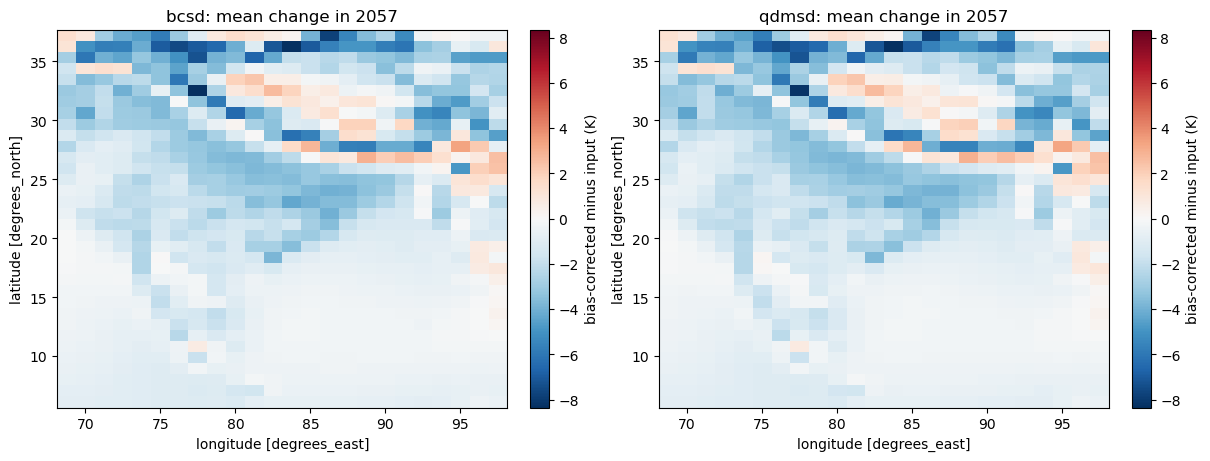

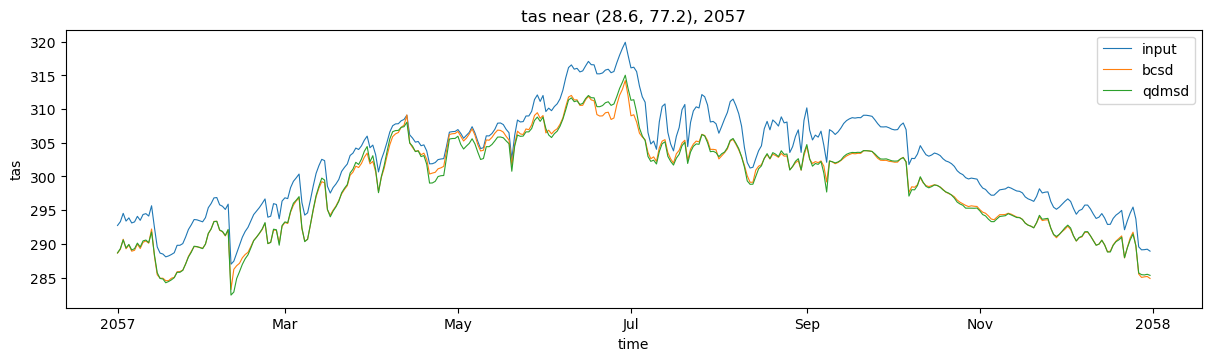

In [8]:
# ===== No modification needed - bias-corrected minus input, on the identical grid =====
if compare_year is None:
    first, last = coverage(scenario_name, variable_name, gcm_name, resolved_member, exact=True)
    compare_year = str((int(first[:4]) + int(last[:4])) // 2)
year = slice(f"{compare_year}-01-01", f"{compare_year}-12-31")

raw = ds[variable_name].sel(time=year)
corrected = {
    method: load_bias_corrected(scenario_name, variable_name, gcm_name, method, resolved_member)[variable_name].sel(time=year)
    for method in ("bcsd", "qdmsd")
}
total = describe_request(raw.sel(**compare_region), quiet=True) + sum(
    describe_request(c.sel(**compare_region), quiet=True) for c in corrected.values()
)
print(f"comparing {compare_year}; this reads about {total / 1e6:.0f} MB\n")

changes = {m: (c.sel(**compare_region) - raw.sel(**compare_region)).mean("time") for m, c in corrected.items()}
series = {"input": raw.sel(**compare_point, method="nearest")}
series |= {m: c.sel(**compare_point, method="nearest") for m, c in corrected.items()}
# One graph, so the input chunks are read once for both the maps and the series.
changes, series = dask.compute(changes, series)

units = ds[variable_name].attrs.get("units", "")
for method, change in changes.items():
    weights = np.cos(np.deg2rad(change.lat))
    print(f"{method}: mean change over the region {float(change.weighted(weights).mean()):+.2f} {units}, "
          f"cells range {float(change.min()):+.2f} to {float(change.max()):+.2f}")

limit = max(abs(float(v)) for change in changes.values() for v in (change.min(), change.max()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, (method, change) in zip(axes, changes.items()):
    change.plot(ax=ax, cmap="RdBu_r", vmin=-limit, vmax=limit,
                cbar_kwargs={"label": f"bias-corrected minus input ({units})"})
    ax.set_title(f"{method}: mean change in {compare_year}")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
for name, values in series.items():
    values.plot(ax=ax, label=name, linewidth=0.8)
ax.set_title(f"{variable_name} near ({compare_point['lat']}, {compare_point['lon']}), {compare_year}")
ax.legend()
plt.show()

The maps show where, and by how much, each method moved the GCM toward the observations it was trained against. Where the two maps agree, the correction is robust to the choice of method; where they differ, the result depends on it. The time series shows the same thing at one location, day by day.

For what downscaling then adds on top of this, see Section 8 of [`subsetting-and-exporting.ipynb`](subsetting-and-exporting.ipynb).

## 6. Export

Exports are named like the published output files, with `input` where the downscaling method would be, so they never collide with a downscaled or bias-corrected download of the same selection.

In [9]:
# ===== CUSTOMIZE: where exports go =====
output_dir = Path("./exports")
export_label = "delhi"
# =======================================

# No modification needed below
output_dir.mkdir(exist_ok=True)


def _ready_to_write(selection):
    """Drop encoding inherited from the store (it describes the full grid) and None attrs."""
    for name in selection.variables:
        selection[name].encoding = {}
    selection.attrs = {k: ("" if v is None else v) for k, v in selection.attrs.items()}
    return selection


point_series = _ready_to_write(ds.sel(time=year).sel(**compare_point, method="nearest"))
netcdf_path = output_dir / output_filename(scenario_name, variable_name, year.start, year.stop,
                                           gcm=gcm_name, member=resolved_member, label=export_label)
point_series.to_netcdf(netcdf_path)
print(f"wrote {netcdf_path} ({netcdf_path.stat().st_size / 1e3:.1f} kB)")

region_year = _ready_to_write(ds.sel(time=year).sel(**compare_region))
zarr_path = output_dir / output_filename(scenario_name, variable_name, year.start, year.stop,
                                         gcm=gcm_name, member=resolved_member, label="india", suffix=".zarr")
# Zarr needs uniform chunks, and a year rarely starts on a chunk boundary.
region_year.chunk("auto").to_zarr(zarr_path, mode="w")
print(f"wrote {zarr_path}")

print(f"\nmodel attribute in the exported file: {xr.open_dataset(netcdf_path).attrs['model']!r}")

wrote exports/delhi_CESM2-WACCM6_input_ssp245_003_tas_2057-2057.nc (7.6 kB)


/Users/andersy005/devel/carbonplan/srm-downscaling-data-utils/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


wrote exports/india_CESM2-WACCM6_input_ssp245_003_tas_2057-2057.zarr

model attribute in the exported file: 'CESM2-WACCM6'


For clipping to a country, seasonal selections, unit conversions and other export formats, the patterns in [`subsetting-and-exporting.ipynb`](subsetting-and-exporting.ipynb) apply unchanged to the dataset loaded here. For a file without a notebook, use `./scripts/download.sh --product input`.